In [3]:
import numpy as np
import matplotlib.pyplot as plt


x = 2 * np.random.rand(100 , 1)
y = 4 + 3 * x +np .random.randn(100 , 1)



In [4]:
print(x.shape)

(100, 1)


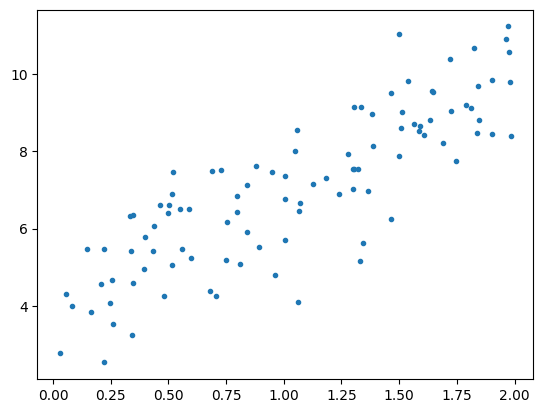

In [5]:
plt.plot( x  , y , ".")
plt.show()

In [6]:
x_b = np.c_[np.ones((100 , 1)) , x] # add x0 = 1 to each instance
theta = np.linalg.inv(x_b.T.dot(x_b)).dot(x_b.T.dot(y)) #Normal equation = (X^t * x)^-1 *X^T *y
                                                        #Gives the best value of thetha that minimizes the cost function
theta

array([[3.94090409],
       [2.96321293]])

In [7]:
x_new = np.array([[0] , [2]])
print(x_new.shape)
x_new_predict = np.c_[np.ones((2 , 1)) , x_new] #[np.ones((dimensions)) , same dimension ko object]
print(theta.shape)
y_predict = x_new_predict.dot(theta)
y_predict


(2, 1)
(2, 1)


array([[3.94090409],
       [9.86732995]])

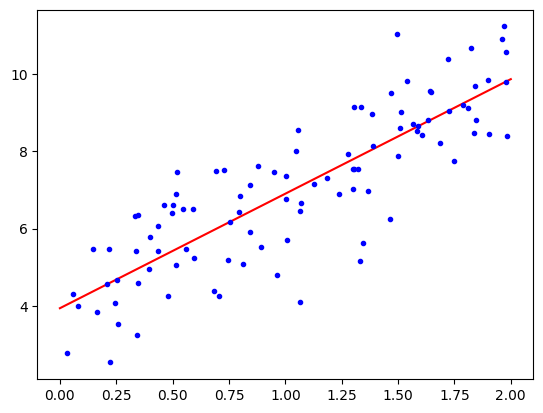

In [8]:
plt.plot(x_new , y_predict , "r-")
plt.plot(x , y, "b.")
plt.show()

In [9]:
#In terms of sklearn

from sklearn.linear_model import LinearRegression

linear = LinearRegression()
linear.fit(x , y)


LinearRegression()

In [10]:
print(linear.intercept_) #Bias thetha 
print(linear.coef_) # Feature weight

[3.94090409]
[[2.96321293]]


In [11]:
#Gradient descent implementation

eta = 0.1 #The learning rate
n_iterations = 1000
m = 100

theta = np.random.rand(2,1) #Since two values for the theta thetha0 and theta1


for iteration in range(n_iterations):
    gradient = (2/m) * x_b.T.dot(x_b.dot(theta) - y) #Uses whole training set in each iteration
    theta = theta - eta * gradient

theta


array([[3.94090409],
       [2.96321293]])

In [12]:
#Stiochastic Gradient descent implementation
n_epochs = 50
t0 , t1 = 5 ,50

theta_1 = np.random.rand(2 ,1)


def learning_rate(t):
    return t0 / (t + t1) #Take Large steps at first as t1>>t and as iteration increases then t>>t1 and small steps


for epochs in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        x_i = x_b[random_index : random_index + 1]
        y_i = y[random_index : random_index + 1]
        gradient = (2) * x_i.T.dot(x_i.dot(theta_1) - y_i) #This is the normal equation here
        eta = learning_rate(epochs * m + i)
        theta_1 = theta_1 - eta * gradient


In [13]:
theta_1

array([[3.96569192],
       [2.9655647 ]])

In [14]:
from sklearn.linear_model import SGDRegressor

regressor = SGDRegressor(n_iter_no_change = 50 , eta0=0.1 , penalty = None)
regressor.fit(x , y)



c:\Users\TRITON\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SGDRegressor(eta0=0.1, n_iter_no_change=50, penalty=None)

In [15]:
theta_0 = regressor.intercept_
theta_01 = regressor.coef_


In [16]:
#Polynomial Regression
m = 100
x_pol = 6 * np.random.rand(m,1) - 3
y_pol = 0.5*  x_pol**2  + x_pol + 2 + np.random.rand(m , 1)

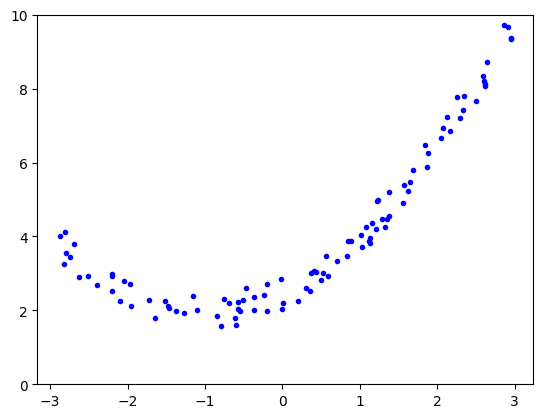

In [17]:
plt.plot(x_pol , y_pol , "b.")
plt.ylim(0 , 10)
plt.show()

In [18]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree= 2 , include_bias=False)
x_poly = poly_features.fit_transform(x_pol)

In [19]:
print(x_pol[0])
print(x_poly[0])

[0.88865464]
[0.88865464 0.78970707]


In [20]:
linear_reg = LinearRegression()
linear_reg.fit(x_poly , y_pol)


LinearRegression()

In [21]:
x_test = np.linspace(-3 , 3 , 200).reshape(-1 , 1)
x_test_poly = poly_features.transform(x_test)
y_pred = linear_reg.predict(x_test_poly)

(0.0, 10.0)

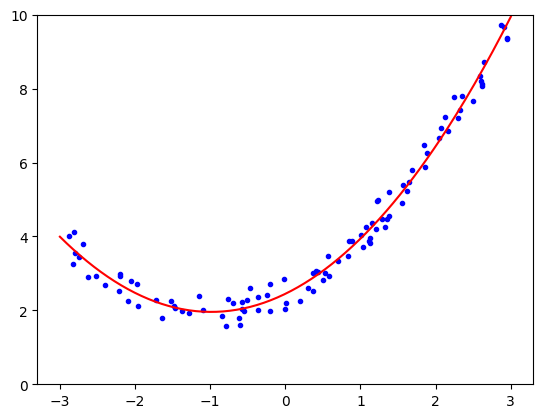

In [22]:
plt.plot(x_pol , y_pol  , "b.")
plt.plot(x_test , y_pred , "r-")
plt.ylim(0 , 10)

In [23]:
print(y_pol.shape)

(100, 1)


In [24]:
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_squared_error

def plots(model , x, y):
    x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)
    train_error , val_error = [] , []
    for m in range(1 , len(x_train)):
        model.fit(x_train[:m] , y_train[:m])
        y_train_predict = model.predict(x_train[:m])
        y_val_predict = model.predict(x_test)
        train_error.append(mean_squared_error(y_train[:m] , y_train_predict))
        val_error.append(mean_squared_error(y_test, y_val_predict))
    plt.plot(np.sqrt(train_error) , "r-+" , linewidth = 2 , label = "Trainig error")
    plt.plot(np.sqrt(val_error) , "b-" , linewidth = 2 , label = "ValueError")
    plt.xlabel("Trainig set size")
    plt.ylabel("RMSE")
    plt.legend()

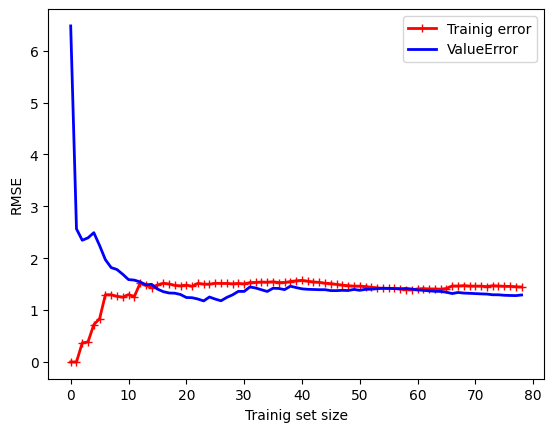

In [25]:
liner = LinearRegression()
plots(liner , x_pol , y_pol)

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline 
from sklearn.linear_model import Ridge

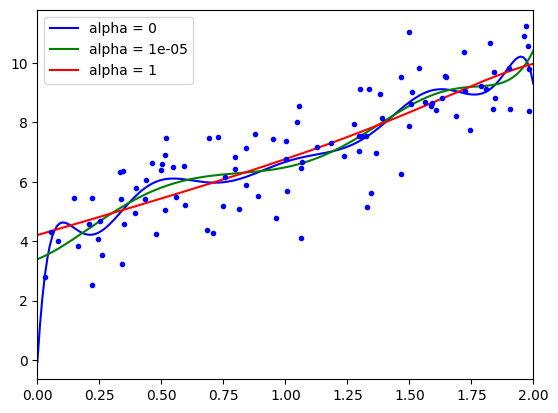

In [27]:
alphas = [0 ,1e-05 ,1]
labels_1 = ["b-" ,"g-", "r-"]

for alpha_1 , label_1 in zip(alphas , labels_1):
    polynomial_regression = Pipeline([
    ("poly_features" , PolynomialFeatures(degree=10 , include_bias=False)),
    ("scaling" , StandardScaler()),
    ('ridge' , Ridge(alpha = alpha_1 , solver="cholesky"))
])
    polynomial_regression.fit(x , y)

    x_test_1 = np.linspace(0 , 2, 200).reshape(-1 , 1)
    y_pred_2 = polynomial_regression.predict(x_test_1)
    plt.plot(x_test_1 , y_pred_2 , label_1 , label = f'alpha = {alpha_1}')


plt.plot(x , y, "b." )
plt.xlim(0 , 2)
plt.legend()
plt.show()

    

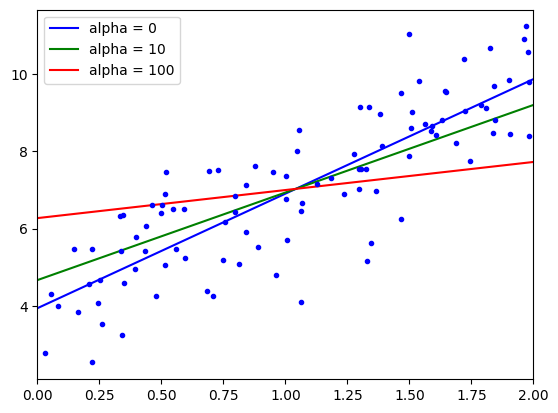

In [28]:
alphas = [0 ,10 ,100]
labels_1 = ["b-" ,"g-", "r-"]

for alpha_1 , label_1 in zip(alphas , labels_1):
    polynomial_regression = Pipeline([
    ('ridge' , Ridge(alpha = alpha_1 , solver="cholesky"))
])
    polynomial_regression.fit(x , y)

    x_test_1 = np.linspace(0 , 2, 200).reshape(-1 , 1)
    y_pred_2 = polynomial_regression.predict(x_test_1)
    plt.plot(x_test_1 , y_pred_2 , label_1 , label = f'alpha = {alpha_1}')


plt.plot(x , y, "b." )
plt.xlim(0 , 2)
plt.legend()
plt.show()

    

In [29]:
ridge_reg = Ridge(alpha= 1 , solver= "cholesky")
ridge_reg.fit( x , y)
ridge_reg.predict([[1.5]])

array([8.34517973])

In [30]:
sg = SGDRegressor(penalty="l2") 
sg.fit(x , y)
sg.predict([[1.5]])

c:\Users\TRITON\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([8.47878774])

c:\Users\TRITON\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\TRITON\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\TRITON\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.638e+01, tolerance: 4.014e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solver

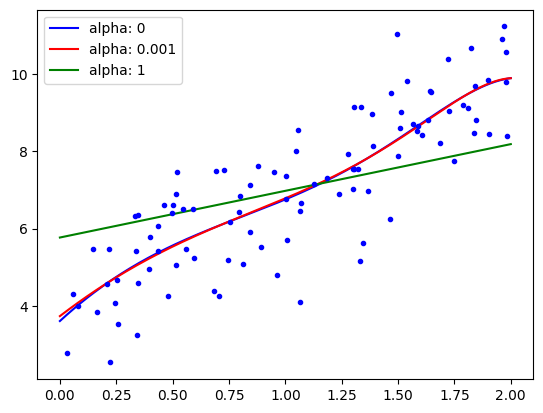

In [31]:
from sklearn.linear_model import Lasso

alphas = [0 , 0.001 , 1]
labels = ["b-", "r-" , "g-"]

for alpha_2 , label_2 in zip(alphas , labels):
    pipe = Pipeline([
        ("polynomial" , PolynomialFeatures(degree=10 , include_bias=False)),
        ("scaler" , StandardScaler()),
        ("laso" , Lasso(alpha=alpha_2))
    ]) 
    pipe.fit(x , y)
    x_test = np.linspace(0 , 2 , 200).reshape(-1 , 1)
    y_pred = pipe.predict(x_test)
    plt.plot(x_test , y_pred , label_2 , label = f"alpha: {alpha_2}")

plt.plot(x , y , "b.")
plt.legend()
plt.show()

c:\Users\TRITON\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\TRITON\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\TRITON\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.819e+01, tolerance: 4.014e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solver

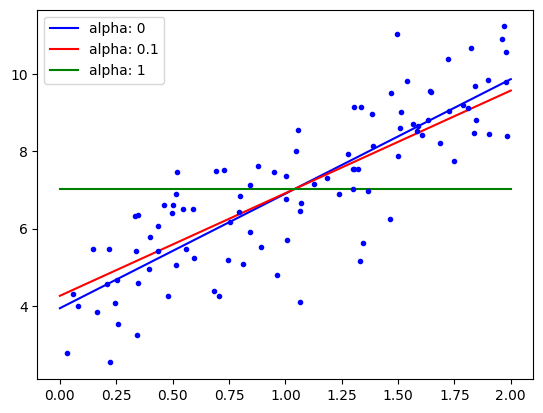

In [32]:
from sklearn.linear_model import Lasso

alphas = [0 , 0.1 , 1]
labels = ["b-", "r-" , "g-"]

for alpha_2 , label_2 in zip(alphas , labels):
    pipe = Pipeline([
        ("laso" , Lasso(alpha=alpha_2))
    ]) 
    pipe.fit(x , y)
    x_test = np.linspace(0 , 2 , 200).reshape(-1 , 1)
    y_pred = pipe.predict(x_test)
    plt.plot(x_test , y_pred , label_2 , label = f"alpha: {alpha_2}")

plt.plot(x , y , "b.")
plt.legend()
plt.show()

In [33]:
las = Lasso(alpha= 0.1)
las.fit(x , y)
las.predict([[1.5]])

array([8.24468545])

In [34]:
#Elastic Net
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(alpha= 0.1 , l1_ratio= 0.5)
elastic.fit(x , y)
elastic.predict([[1.5]])

array([8.14354005])

In [35]:
pipe_1 = Pipeline([
    ('polynomial' , PolynomialFeatures(degree=10 , include_bias= False)),
    ('Scaing' , StandardScaler())
]) 

pipe_1.fit(x)

Pipeline(steps=[('polynomial',
                 PolynomialFeatures(degree=10, include_bias=False)),
                ('Scaing', StandardScaler())])

In [36]:
x_train , x_test , y_train , y_test = train_test_split(x , y  , test_size=0.2 , random_state=42)

x_train_transformed = pipe_1.transform(x_train)
x_val_poly_scaled = pipe_1.transform(x_test)
y_train.shape

(80, 1)

In [37]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.base import clone


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
y_train = y_train.ravel()
y_test = y_test.ravel()
x_train_transformed = pipe_1.transform(x_train)
x_val_poly_scaled = pipe_1.transform(x_test)
sgd_reg = SGDRegressor(
    warm_start=True,
    n_iter_no_change=1,
    penalty=None,
    learning_rate="constant",
    eta0=0.0005,
    random_state=42
)

best_model = None
best_epochs = None
minimum_val_error = float("inf")

for epochs in range(1000):
    sgd_reg.fit(x_train_transformed, y_train)
    y_val_predict = sgd_reg.predict(x_val_poly_scaled)
    val_error = mean_squared_error(y_test, y_val_predict)
    
    if val_error < minimum_val_error:
        minimum_val_error = val_error
        best_epochs = epochs
        best_model = clone(sgd_reg)
print(f"Best epochs: {best_epochs}")
print(f"Minimum validation error: {minimum_val_error}")

Best epochs: 999
Minimum validation error: 1.8206472290868807


In [46]:
def plots_1(model ,x ,y ,epochs=500):
    train_errors = []
    val_error = []
    x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)
    y_train = y_train.ravel()
    y_test = y_test.ravel()
    model.set_params(warm_start=True, max_iter=1, tol=None)
    for itera in range(epochs):
        model.fit(x_train , y_train)

        y_train_predict = model.predict(x_train)
        y_test_predict = model.predict(x_test)

        train_errors.append(np.sqrt(mean_squared_error(y_train , y_train_predict)))
        val_error.append(np.sqrt(mean_squared_error(y_test , y_test_predict)))
    
    plt.figure(figsize=(10 , 6))
    plt.plot(train_errors , "r--" , label = "Training set")
    plt.plot(val_error , "b-" , label = "Training set")
    plt.xlabel("Epoch", fontsize=12)
    plt.ylabel("RMSE", fontsize=12)
    plt.legend(fontsize=11, loc='upper right')
    plt.title("Early Stopping Regularization", fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
sg = SGDRegressor( warm_start= True, learning_rate="constant"  , random_state=42  ,penalty=None)
plots_1(sg , x , y)